# 02 — Repeated Nested Cross-Validation Comparison

This notebook runs leakage-safe repeated nested CV. Raw data are passed into complete sklearn pipelines. Preprocessing and feature selection are fitted only within the appropriate training folds.

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd

from src.preprocessing import load_heart_disease, get_estimators_and_param_spaces
from src.rncv import RepeatedNestedCV, RNCVConfig
from src import plotting

DATA_PATH = PROJECT_ROOT / 'data' / 'heart_disease.csv'
X, y = load_heart_disease(DATA_PATH)
estimators, param_spaces = get_estimators_and_param_spaces(random_state=42)
[name for name, _ in estimators]

['LR_ElasticNet', 'GNB', 'LDA', 'RF', 'LightGBM', 'XGBoost', 'CatBoost']

## Configuration

For final submission use `N_ROUNDS=10`, `N_OUTER=5`, `N_INNER=3`. During debugging you can temporarily reduce `N_ROUNDS` or `N_ITER`.

In [2]:
N_ROUNDS = 10
N_OUTER = 5
N_INNER = 3
N_ITER = 40

cfg = RNCVConfig(n_rounds=N_ROUNDS, n_outer=N_OUTER, n_inner=N_INNER, n_iter=N_ITER, random_state=42, scoring='roc_auc', n_jobs=-1)

## Task 3 baseline: repeated 5-fold CV without inner tuning

The assignment asks for a fair default-hyperparameter comparison by disabling the inner loop. This still uses complete pipelines.

In [3]:
baseline_runner = RepeatedNestedCV(estimators, param_spaces={}, config=cfg, use_feature_selection=False)
baseline_results = baseline_runner.run(X, y, tune=False)
baseline_summary = baseline_runner.summarise()
display(baseline_runner.formatted_summary(stage='Default repeated CV'))
baseline_summary.to_csv(PROJECT_ROOT / 'results' / 'baseline_summary.csv')


=== LR_ElasticNet | tune=False | FS=False ===
  round 10/10 complete
=== GNB | tune=False | FS=False ===
  round 10/10 complete
=== LDA | tune=False | FS=False ===
  round 10/10 complete
=== RF | tune=False | FS=False ===
  round 10/10 complete
=== LightGBM | tune=False | FS=False ===
  round 10/10 complete
=== XGBoost | tune=False | FS=False ===
  round 10/10 complete
=== CatBoost | tune=False | FS=False ===
  round 10/10 complete
Done.


,Model,Stage,MCC (95% CI),AUC (95% CI),BA (95% CI),F1 (95% CI),Recall (95% CI),Specificity (95% CI),Precision (95% CI),PRAUC (95% CI)
0,LDA,Default repeated CV,"0.664 [0.629, 0.674]","0.891 [0.885, 0.904]","0.831 [0.807, 0.838]","0.814 [0.780, 0.826]","0.773 [0.727, 0.818]","0.885 [0.846, 0.923]","0.854 [0.826, 0.875]","0.888 [0.877, 0.902]"
1,LR_ElasticNet,Default repeated CV,"0.638 [0.622, 0.667]","0.895 [0.890, 0.904]","0.815 [0.799, 0.832]","0.800 [0.783, 0.821]","0.818 [0.773, 0.818]","0.846 [0.830, 0.885]","0.814 [0.800, 0.840]","0.888 [0.877, 0.904]"
2,LightGBM,Default repeated CV,"0.590 [0.554, 0.622]","0.865 [0.858, 0.874]","0.788 [0.776, 0.804]","0.776 [0.750, 0.791]","0.773 [0.773, 0.818]","0.808 [0.778, 0.846]","0.778 [0.750, 0.792]","0.871 [0.856, 0.877]"
3,CatBoost,Default repeated CV,"0.588 [0.567, 0.624]","0.883 [0.870, 0.896]","0.790 [0.778, 0.809]","0.768 [0.762, 0.795]","0.773 [0.733, 0.818]","0.815 [0.808, 0.846]","0.791 [0.773, 0.800]","0.879 [0.872, 0.890]"
4,RF,Default repeated CV,"0.587 [0.580, 0.626]","0.886 [0.873, 0.895]","0.790 [0.781, 0.809]","0.773 [0.756, 0.790]","0.756 [0.727, 0.773]","0.846 [0.846, 0.868]","0.810 [0.789, 0.833]","0.880 [0.875, 0.899]"
5,XGBoost,Default repeated CV,"0.583 [0.556, 0.593]","0.868 [0.861, 0.876]","0.788 [0.776, 0.796]","0.766 [0.750, 0.783]","0.773 [0.772, 0.783]","0.808 [0.793, 0.846]","0.783 [0.760, 0.810]","0.873 [0.860, 0.877]"
6,GNB,Default repeated CV,"0.490 [0.441, 0.534]","0.866 [0.846, 0.885]","0.724 [0.699, 0.744]","0.744 [0.727, 0.759]","0.909 [0.864, 0.913]","0.509 [0.472, 0.566]","0.616 [0.595, 0.631]","0.848 [0.828, 0.874]"


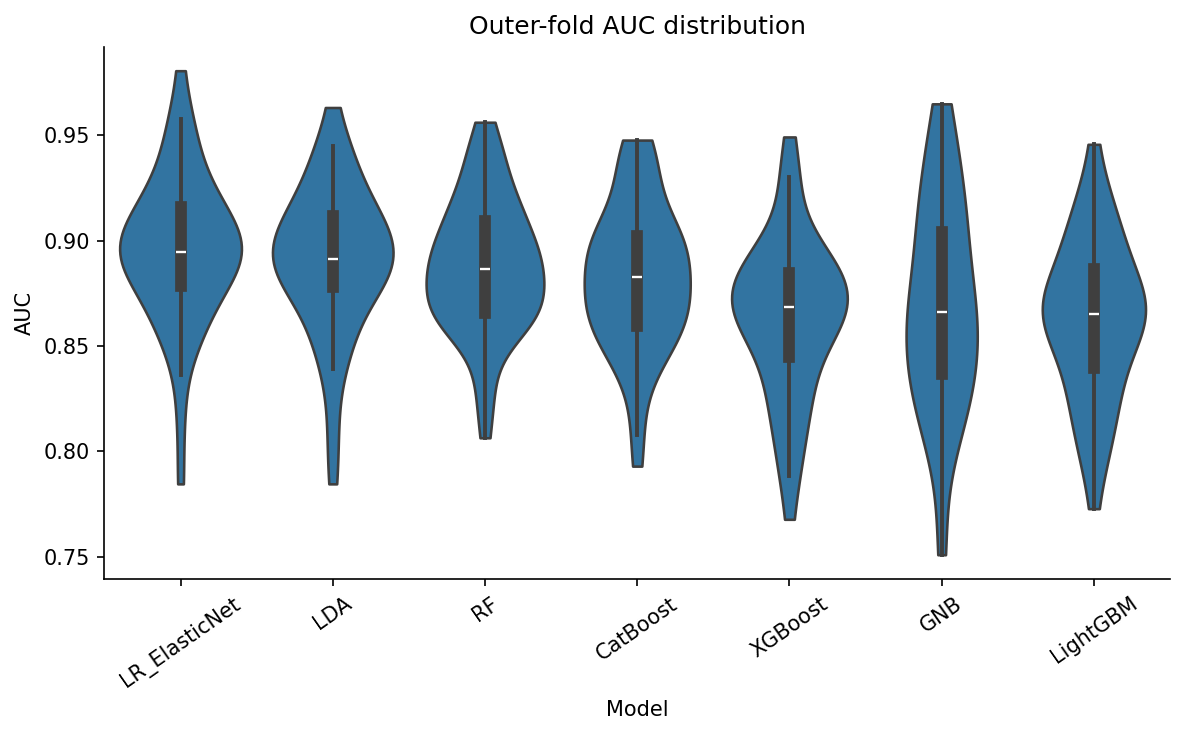

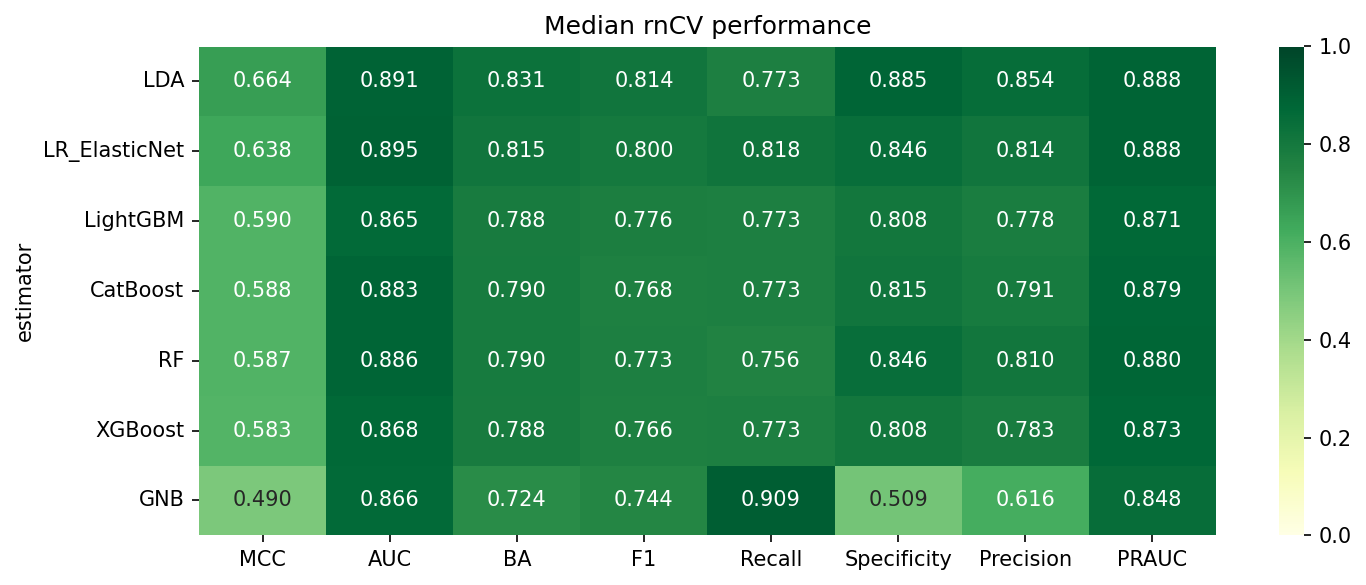

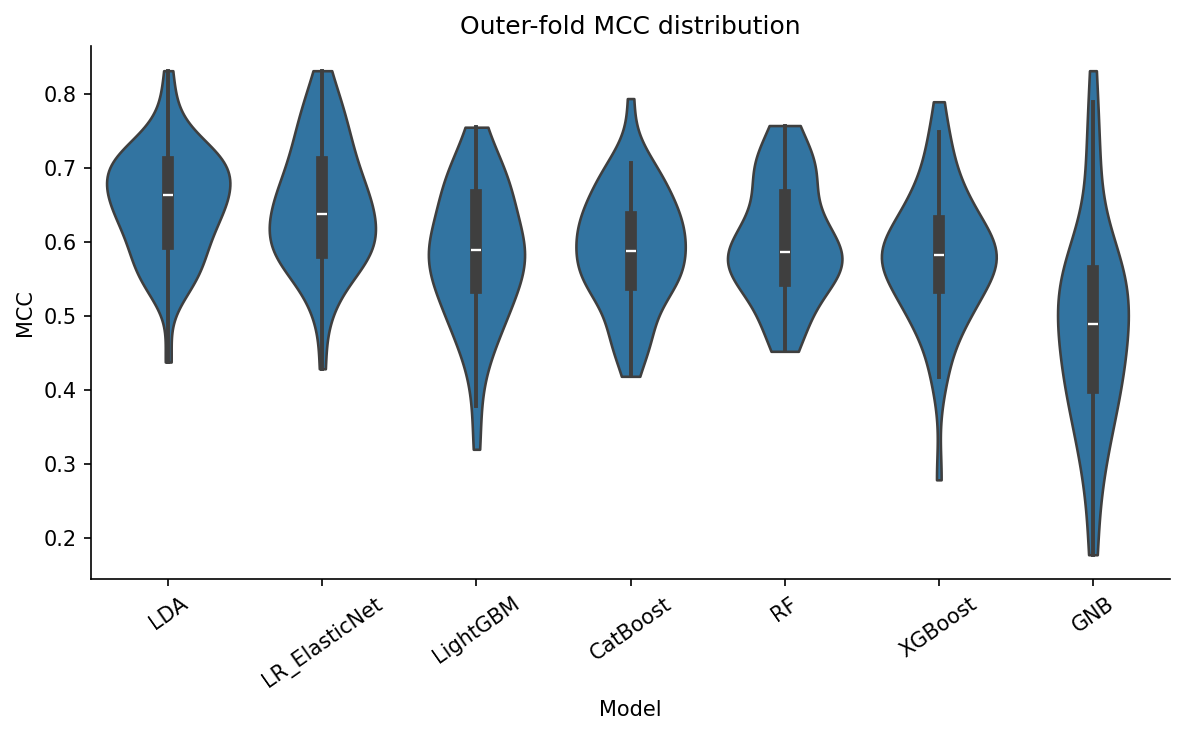

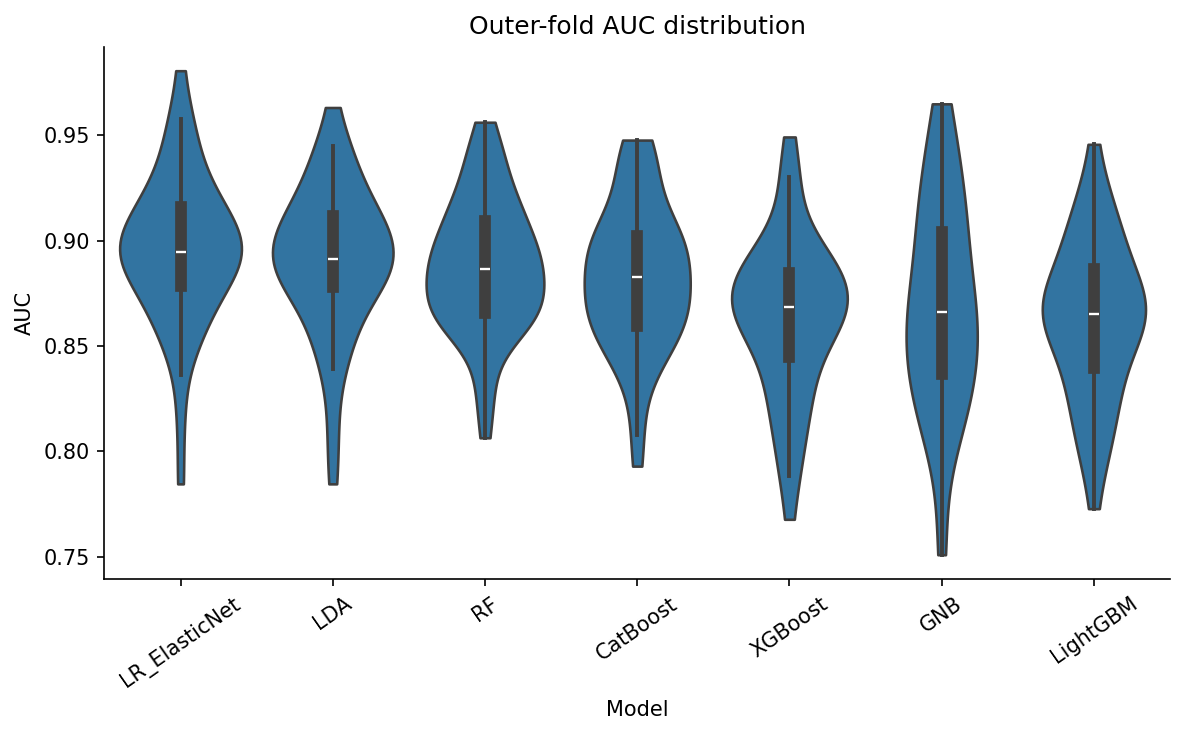

In [4]:
plotting.plot_summary_heatmap(baseline_summary)
plotting.plot_metric_violin(baseline_results, metric='MCC')
plotting.plot_metric_violin(baseline_results, metric='AUC')

## Task 3 rnCV: repeated nested CV with hyperparameter tuning

The inner `RandomizedSearchCV` receives the full pipeline, so imputation, encoding, scaling, and model fitting are refit separately inside every inner training fold.

In [5]:
tuned_runner = RepeatedNestedCV(estimators, param_spaces=param_spaces, config=cfg, use_feature_selection=False)
tuned_results = tuned_runner.run(X, y, tune=True)
tuned_summary = tuned_runner.summarise()
display(tuned_runner.formatted_summary(stage='rnCV tuned, all features'))
tuned_summary.to_csv(PROJECT_ROOT / 'results' / 'tuned_summary.csv')


=== LR_ElasticNet | tune=True | FS=False ===
  round 10/10 complete
=== GNB | tune=True | FS=False ===
  round 10/10 complete
=== LDA | tune=True | FS=False ===
  round 10/10 complete
=== RF | tune=True | FS=False ===
  round 10/10 complete
=== LightGBM | tune=True | FS=False ===
  round 10/10 complete
=== XGBoost | tune=True | FS=False ===
  round 10/10 complete
=== CatBoost | tune=True | FS=False ===
  round 10/10 complete
Done.


,Model,Stage,MCC (95% CI),AUC (95% CI),BA (95% CI),F1 (95% CI),Recall (95% CI),Specificity (95% CI),Precision (95% CI),PRAUC (95% CI)
0,LDA,"rnCV tuned, all features","0.667 [0.630, 0.711]","0.900 [0.889, 0.913]","0.830 [0.809, 0.844]","0.810 [0.791, 0.824]","0.773 [0.739, 0.818]","0.889 [0.885, 0.923]","0.870 [0.842, 0.889]","0.895 [0.886, 0.908]"
1,GNB,"rnCV tuned, all features","0.654 [0.624, 0.698]","0.892 [0.881, 0.904]","0.823 [0.809, 0.843]","0.804 [0.791, 0.829]","0.800 [0.773, 0.822]","0.849 [0.830, 0.885]","0.818 [0.800, 0.850]","0.879 [0.859, 0.896]"
2,XGBoost,"rnCV tuned, all features","0.631 [0.610, 0.664]","0.891 [0.880, 0.904]","0.811 [0.795, 0.827]","0.790 [0.780, 0.809]","0.773 [0.750, 0.783]","0.868 [0.846, 0.885]","0.833 [0.800, 0.850]","0.888 [0.877, 0.898]"
3,LR_ElasticNet,"rnCV tuned, all features","0.629 [0.622, 0.664]","0.893 [0.888, 0.907]","0.813 [0.808, 0.829]","0.800 [0.787, 0.810]","0.773 [0.773, 0.818]","0.846 [0.846, 0.885]","0.818 [0.805, 0.838]","0.887 [0.878, 0.903]"
4,RF,"rnCV tuned, all features","0.629 [0.583, 0.669]","0.894 [0.884, 0.900]","0.812 [0.788, 0.834]","0.791 [0.764, 0.818]","0.773 [0.756, 0.818]","0.846 [0.808, 0.885]","0.808 [0.773, 0.842]","0.894 [0.882, 0.904]"
5,CatBoost,"rnCV tuned, all features","0.624 [0.585, 0.664]","0.891 [0.876, 0.897]","0.808 [0.790, 0.823]","0.790 [0.771, 0.804]","0.783 [0.773, 0.818]","0.846 [0.815, 0.852]","0.800 [0.786, 0.822]","0.887 [0.879, 0.896]"
6,LightGBM,"rnCV tuned, all features","0.622 [0.592, 0.628]","0.888 [0.879, 0.899]","0.804 [0.794, 0.813]","0.791 [0.773, 0.800]","0.800 [0.773, 0.822]","0.846 [0.808, 0.846]","0.800 [0.766, 0.814]","0.885 [0.875, 0.896]"


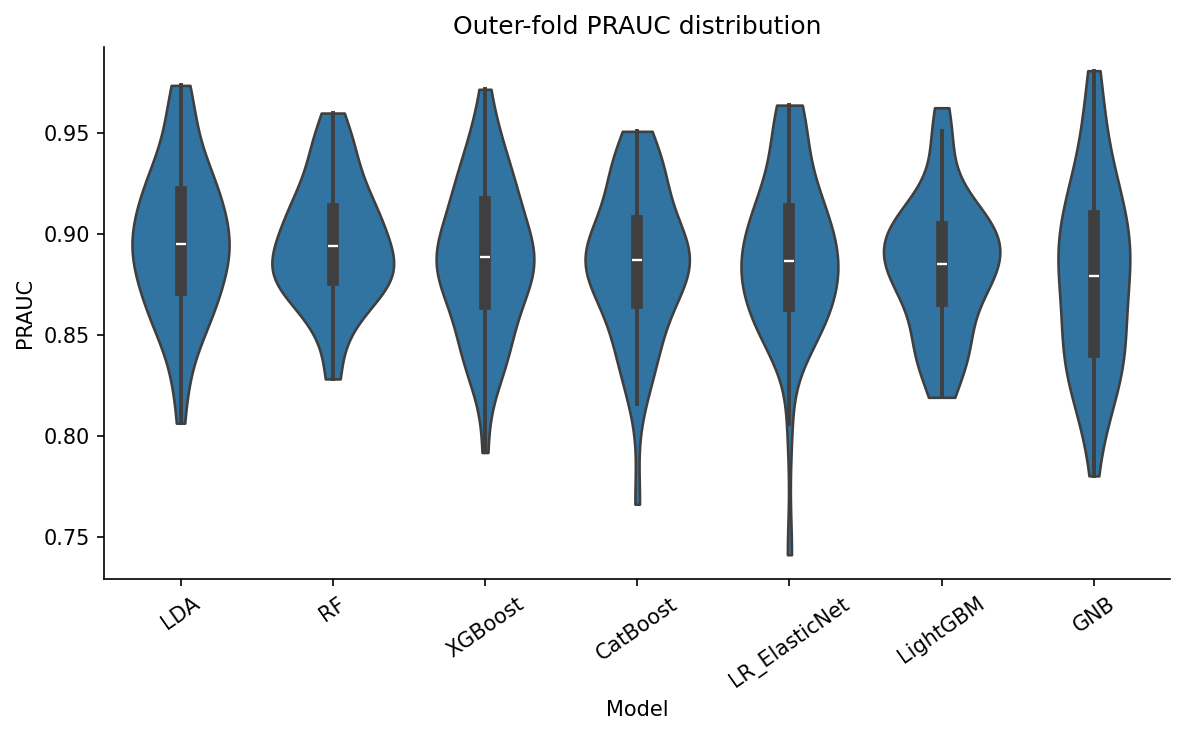

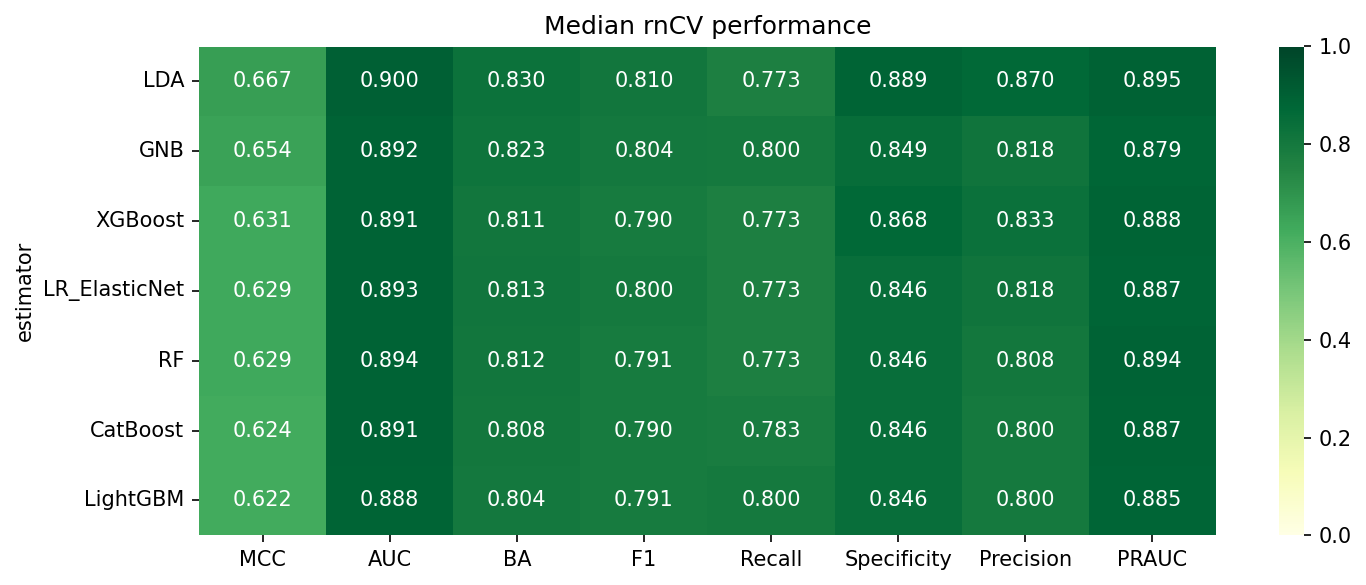

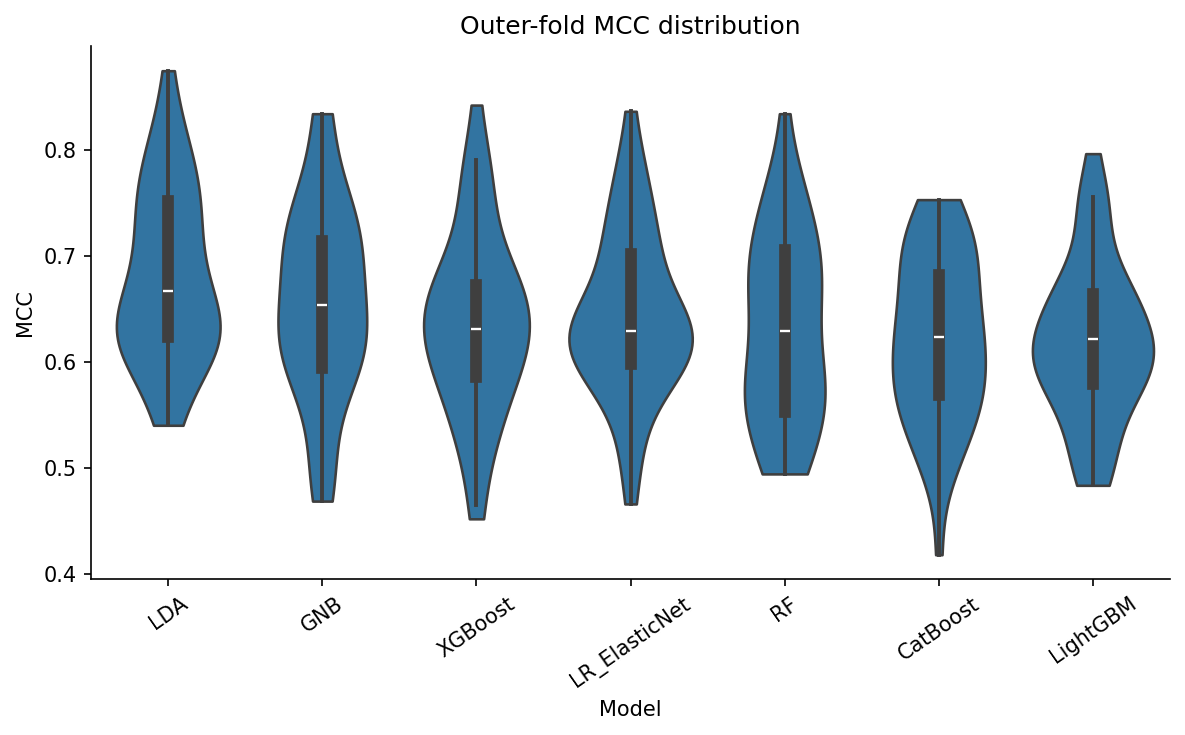

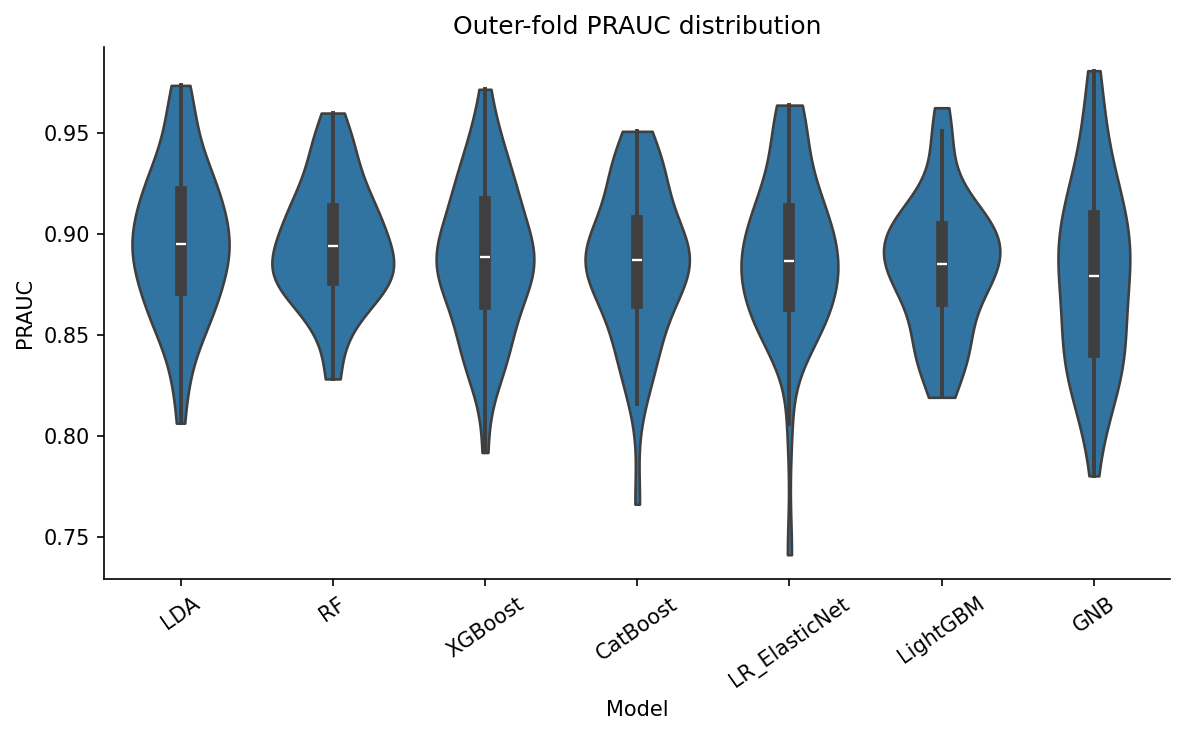

In [6]:
plotting.plot_summary_heatmap(tuned_summary)
plotting.plot_metric_violin(tuned_results, metric='MCC')
plotting.plot_metric_violin(tuned_results, metric='PRAUC')

## Winner selection

Select the winning algorithm using a clinically sensible balance of MCC, recall/specificity, ROC-AUC, and PR-AUC. If top models have overlapping confidence intervals, prefer the simpler and more stable model.

In [7]:
winner_name = tuned_summary.index[0]
print('Provisional winner by median MCC:', winner_name)
winner_estimator = dict(estimators)[winner_name]
winner_space = param_spaces[winner_name]

Provisional winner by median MCC: LDA


## Task 4: feature selection inside rnCV

Feature selection is model-agnostic mutual information (`SelectKBest`) and is inside the pipeline. Therefore, selected features are learned only from each training fold.

In [8]:
winner_only = [(winner_name, winner_estimator)]
fs_runner = RepeatedNestedCV(
    winner_only,
    param_spaces={winner_name: winner_space},
    config=cfg,
    use_feature_selection=True,
    feature_k_grid=[3, 5, 8, 10, 'all'],
)
fs_results = fs_runner.run(X, y, tune=True)
fs_summary = fs_runner.summarise()
display(fs_runner.formatted_summary(stage='rnCV tuned + FS'))
fs_summary.to_csv(PROJECT_ROOT / 'results' / 'feature_selection_summary.csv')


=== LDA | tune=True | FS=True ===
  round 10/10 complete
Done.


,Model,Stage,MCC (95% CI),AUC (95% CI),BA (95% CI),F1 (95% CI),Recall (95% CI),Specificity (95% CI),Precision (95% CI),PRAUC (95% CI)
0,LDA,rnCV tuned + FS,"0.667 [0.628, 0.711]","0.901 [0.888, 0.909]","0.826 [0.810, 0.841]","0.805 [0.791, 0.823]","0.756 [0.727, 0.795]","0.885 [0.885, 0.923]","0.850 [0.842, 0.889]","0.893 [0.882, 0.908]"


In [9]:
# How often was each K selected?
k_counts = fs_results[winner_name]["selected_k"].value_counts().reset_index()
k_counts.columns = ["K", "count"]
k_counts["frequency_%"] = 100 * k_counts["count"] / k_counts["count"].sum()

display(k_counts)

k_counts.to_csv(PROJECT_ROOT / "results" / "selected_k_frequency.csv", index=False)

# Performance by selected K
k_perf = (
    fs_results[winner_name]
    .groupby("selected_k")[["MCC", "AUC", "BA", "F1", "Recall", "Specificity", "Precision", "PRAUC"]]
    .median()
    .sort_values("MCC", ascending=False)
)

display(k_perf)

k_perf.to_csv(PROJECT_ROOT / "results" / "performance_by_selected_k.csv")

,K,count,frequency_%
0,all,28,56.0
1,10,14,28.0
2,8,8,16.0


,MCC,AUC,BA,F1,Recall,Specificity,Precision,PRAUC
selected_k,,,,,,,,
8,0.669274,0.920304,0.833236,0.817805,0.818182,0.888889,0.856818,0.920466
10,0.652796,0.899666,0.824529,0.810256,0.755929,0.884615,0.846053,0.883887
all,0.651566,0.890216,0.822286,0.800000,0.739130,0.884615,0.859783,0.889796


In [10]:
fixed_k_results = []
fixed_k_summaries = {}

for k in [3, 5, 8, 10, "all"]:
    print(f"\nRunning fixed K = {k}")

    runner_k = RepeatedNestedCV(
        winner_only,
        param_spaces={winner_name: winner_space},
        config=cfg,
        use_feature_selection=True,
        feature_k_grid=[k],
    )

    runner_k.run(X, y, tune=True)
    summary_k = runner_k.summarise()
    fixed_k_summaries[k] = summary_k

    row = summary_k.loc[winner_name].copy()
    row["K"] = k
    fixed_k_results.append(row)

fixed_k_table = pd.DataFrame(fixed_k_results).set_index("K")
display(fixed_k_table)

fixed_k_table.to_csv(PROJECT_ROOT / "results" / "fixed_k_feature_selection_comparison.csv")


Running fixed K = 3

=== LDA | tune=True | FS=True ===
  round 10/10 complete
Done.

Running fixed K = 5

=== LDA | tune=True | FS=True ===
  round 10/10 complete
Done.

Running fixed K = 8

=== LDA | tune=True | FS=True ===
  round 10/10 complete
Done.

Running fixed K = 10

=== LDA | tune=True | FS=True ===
  round 10/10 complete
Done.

Running fixed K = all

=== LDA | tune=True | FS=True ===
  round 10/10 complete
Done.


,MCC_median,MCC_CI_lo,MCC_CI_hi,AUC_median,AUC_CI_lo,AUC_CI_hi,BA_median,BA_CI_lo,BA_CI_hi,F1_median,...,Recall_CI_hi,Specificity_median,Specificity_CI_lo,Specificity_CI_hi,Precision_median,Precision_CI_lo,Precision_CI_hi,PRAUC_median,PRAUC_CI_lo,PRAUC_CI_hi
K,,,,,,,,,,,,,,,,,,,,,
3.0,0.579979,0.535470,0.590240,0.837898,0.821241,0.855769,0.779720,0.762821,0.791426,0.755556,...,0.772727,0.807692,0.777778,0.846154,0.772727,0.744565,0.800000,0.804868,0.788065,0.815017
5.0,0.632113,0.589427,0.664348,0.876938,0.867003,0.881993,0.813335,0.793771,0.828671,0.795833,...,0.772727,0.884615,0.846154,0.884615,0.833333,0.818182,0.850000,0.863290,0.843662,0.874508
8.0,0.663439,0.633351,0.669342,0.898796,0.889860,0.907343,0.821032,0.809441,0.830808,0.800000,...,0.772727,0.884615,0.884615,0.886752,0.850000,0.842105,0.863636,0.895266,0.877149,0.905243
10.0,0.645150,0.621604,0.670897,0.898601,0.884615,0.903069,0.812613,0.797659,0.829740,0.791182,...,0.777668,0.884615,0.884615,0.884615,0.846053,0.823529,0.863636,0.887617,0.873893,0.906177
all,0.666845,0.630192,0.711015,0.900350,0.888948,0.912815,0.829888,0.809441,0.844406,0.809524,...,0.818182,0.888889,0.884615,0.923077,0.869565,0.842105,0.888889,0.894797,0.886190,0.907583


,estimator,feature,selection_count,selection_frequency_%
0,LDA,ca,50,100.0
1,LDA,cp_4.0,50,100.0
2,LDA,thal_3.0,50,100.0
3,LDA,thal_7.0,50,100.0
4,LDA,exang,49,98.0
5,LDA,slope_1.0,46,92.0
6,LDA,thalach,44,88.0
7,LDA,oldpeak,44,88.0
8,LDA,slope_2.0,40,80.0
9,LDA,sex,37,74.0


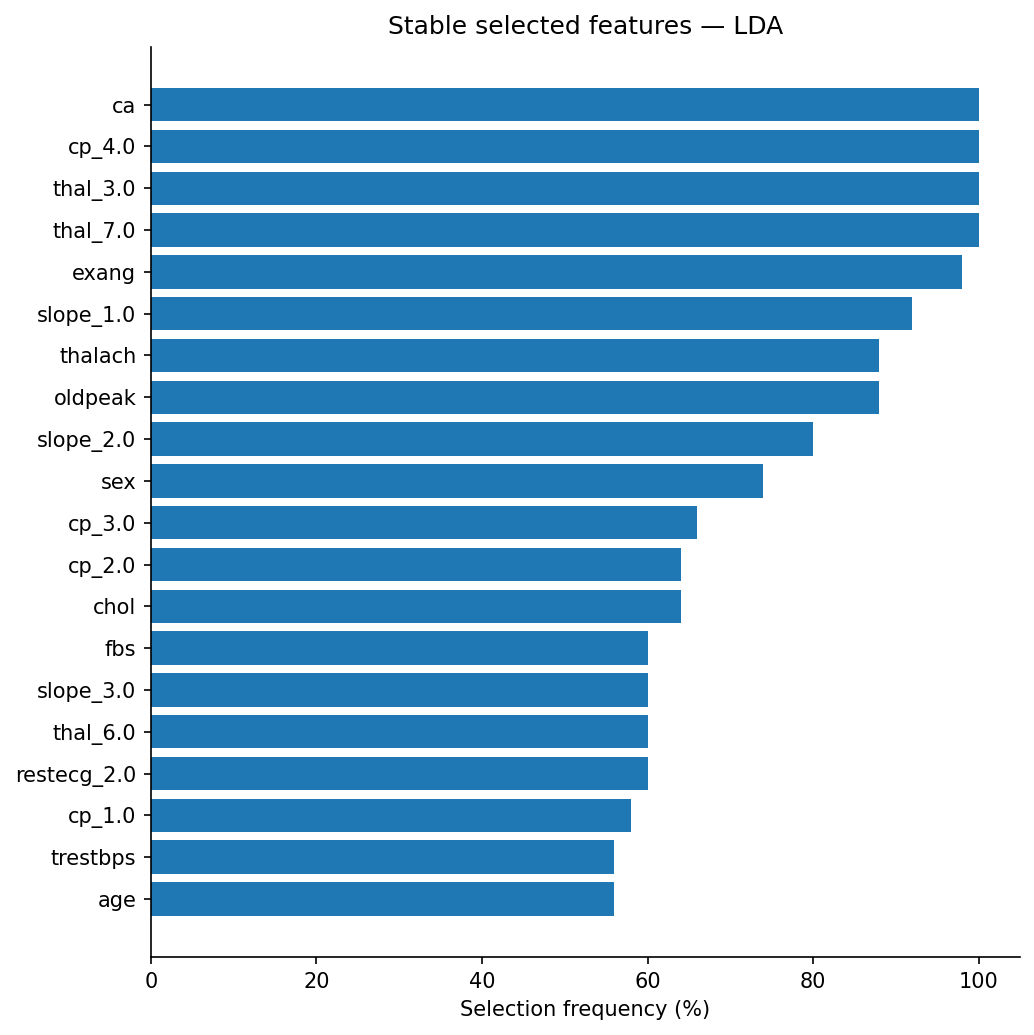

In [11]:
fs_report = fs_runner.feature_selection_report()
display(fs_report.head(30))
fs_report.to_csv(PROJECT_ROOT / 'results' / 'feature_selection_frequency.csv', index=False)
plotting.plot_feature_selection_frequency(fs_report, estimator=winner_name, top_n=20);

In [12]:
print(
    "Final selected K:",
    fs_runner.best_params_[winner_name][-1].get(
        "feature_select__k",
        "all"
    )
)

Final selected K: all


In [13]:
full_winner_table = tuned_runner.formatted_summary(stage="rnCV tuned full features")
full_winner_table = full_winner_table[full_winner_table["Model"] == winner_name]

fs_table = fs_runner.formatted_summary(stage="rnCV tuned + FS")

comparison_table = pd.concat([full_winner_table, fs_table], ignore_index=True)
display(comparison_table)

comparison_table.to_csv(PROJECT_ROOT / "results" / "task4_full_vs_fs_comparison.csv", index=False)

,Model,Stage,MCC (95% CI),AUC (95% CI),BA (95% CI),F1 (95% CI),Recall (95% CI),Specificity (95% CI),Precision (95% CI),PRAUC (95% CI)
0,LDA,rnCV tuned full features,"0.667 [0.630, 0.711]","0.900 [0.889, 0.913]","0.830 [0.809, 0.844]","0.810 [0.791, 0.824]","0.773 [0.739, 0.818]","0.889 [0.885, 0.923]","0.870 [0.842, 0.889]","0.895 [0.886, 0.908]"
1,LDA,rnCV tuned + FS,"0.667 [0.628, 0.711]","0.901 [0.888, 0.909]","0.826 [0.810, 0.841]","0.805 [0.791, 0.823]","0.756 [0.727, 0.795]","0.885 [0.885, 0.923]","0.850 [0.842, 0.889]","0.893 [0.882, 0.908]"


## Comparison note

Compare the all-feature tuned rnCV result against the feature-selection rnCV result using the same winner model and same metrics. Do not mix metrics from different datasets or protocols.